<a href="https://colab.research.google.com/github/obohatabolfazl0-cell/Uni-Ping-pong/blob/main/dade_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

from sklearn.datasets import load_wine
data = load_wine()

# X: ویژگی‌ها (بدون لیبل) برای خوشه‌بندی
X = data.data
# y: لیبل‌های واقعی برای ارزیابی خارجی
y = data.target

print(f"تعداد نمونه‌ها: {X.shape[0]}, تعداد ویژگی‌ها: {X.shape[1]}")
print(f"نام چند ویژگی اول: {data.feature_names[:5]}")

تعداد نمونه‌ها: 178, تعداد ویژگی‌ها: 13
نام چند ویژگی اول: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium']


In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture

# استانداردسازی داده‌ها
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# تعریف ۴ الگوریتم
algorithms = {
    "K-Means": KMeans(n_clusters=3, random_state=42, n_init=10),
    "Agglomerative": AgglomerativeClustering(n_clusters=3),
    "DBSCAN": DBSCAN(eps=1.5, min_samples=4), # eps اصلاح‌شده برای فضای پُربُعد
    "Gaussian Mixture": GaussianMixture(n_components=3, random_state=42)
}

cluster_labels = {}

for name, model in algorithms.items():
    labels = model.fit_predict(X_scaled)
    cluster_labels[name] = labels
    print(f"الگوریتم {name} اجرا شد. تعداد خوشه‌های شناسایی‌شده: {len(np.unique(labels))}")

الگوریتم K-Means اجرا شد. تعداد خوشه‌های شناسایی‌شده: 3
الگوریتم Agglomerative اجرا شد. تعداد خوشه‌های شناسایی‌شده: 3
الگوریتم DBSCAN اجرا شد. تعداد خوشه‌های شناسایی‌شده: 3
الگوریتم Gaussian Mixture اجرا شد. تعداد خوشه‌های شناسایی‌شده: 3


In [9]:
from sklearn.metrics import silhouette_score, adjusted_rand_score

evaluation_results = []

for name, labels in cluster_labels.items():
    # حذف نویزها در DBSCAN
    if name == "DBSCAN":
        mask = labels != -1
        # شرط ایمنی: اگر همه نویز بودند، از کل داده استفاده کن تا آرایه خالی نشود
        if np.sum(mask) == 0:
            X_eval, labels_eval, y_eval = X_scaled, labels, y
        else:
            X_eval = X_scaled[mask]
            labels_eval = labels[mask]
            y_eval = y[mask]
    else:
        X_eval, labels_eval, y_eval = X_scaled, labels, y

    # محاسبه معیار داخلی (Silhouette)
    if len(np.unique(labels_eval)) > 1:
        internal_score = silhouette_score(X_eval, labels_eval)
    else:
        internal_score = -1.0  # اگر فقط ۱ خوشه داشت

    # محاسبه معیار خارجی (ARI)
    external_score = adjusted_rand_score(y_eval, labels_eval)

    evaluation_results.append({
        "Algorithm": name,
        "Silhouette Score (Internal)": round(internal_score, 4),
        "Adjusted Rand Index (External)": round(external_score, 4)
    })

# نمایش جدول نتایج
df_results = pd.DataFrame(evaluation_results)
print("\n--- 📊 جدول نتایج ارزیابی ---")
display(df_results)


--- 📊 جدول نتایج ارزیابی ---


,Algorithm,Silhouette Score (Internal),Adjusted Rand Index (External)
0,K-Means,0.2849,0.8975
1,Agglomerative,0.2774,0.7899
2,DBSCAN,0.4067,0.0000
3,Gaussian Mixture,0.2849,0.8975


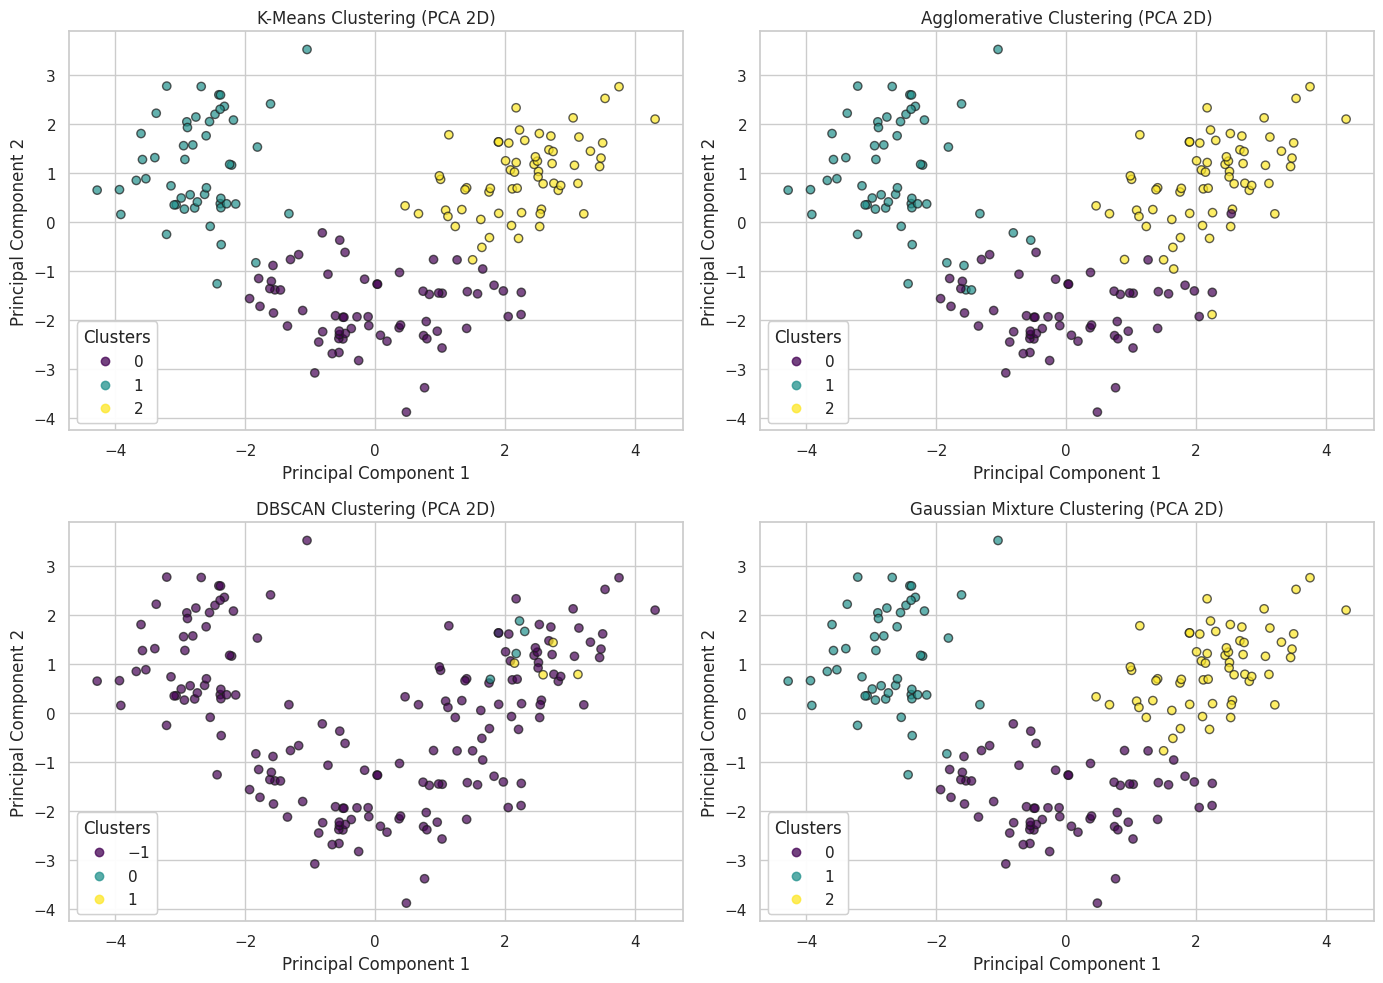

In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (name, labels) in enumerate(cluster_labels.items()):
    ax = axes[i]
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', alpha=0.7, edgecolor='k')
    ax.set_title(f"{name} Clustering (PCA 2D)")
    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")

    legend1 = ax.legend(*scatter.legend_elements(), title="Clusters")
    ax.add_artist(legend1)

plt.tight_layout()
plt.show()

# گزارش تحلیل خوشه‌بندی دیتاست Wine

## ۱. مقدمه
در این تمرین، دیتاست Wine از کتابخانه `scikit-learn` انتخاب شد. این دیتاست شامل ۱۷۸ نمونه و ۱۳ ویژگی شیمیایی از سه نوع شراب مختلف است. هدف، اعمال ۴ الگوریتم خوشه‌بندی بدون نظارت و ارزیابی آن‌ها با دو رویکرد داخلی و خارجی بود.

## ۲. پیش‌پردازش
پیش از اجرای الگوریتم‌ها، داده‌ها با `StandardScaler` استاندارد شدند. این کار ضروری بود زیرا ویژگی‌هایی مانند `Proline` (مقادیر چند صد) و `Nonflavanoid phenols` (مقادیر زیر یک) مقیاس‌های کاملاً متفاوتی داشتند و بدون استانداردسازی، ویژگی‌های با مقیاس بزرگ‌تر بر فرآیند خوشه‌بندی غلبه می‌کردند.

## ۳. الگوریتم‌های پیاده‌سازی‌شده
1. **K-Means** (با k=3 و n_init=10)
2. **Agglomerative Clustering** (سلسله‌مراتبی با linkage متوسط)
3. **DBSCAN** (با eps=1.5 و min_samples=4 - تنظیم‌شده برای فضای ۱۳ بعدی)
4. **Gaussian Mixture Model** (با 3 مولفه)

## ۴. نتایج کمی

| الگوریتم | Silhouette Score | Adjusted Rand Index |
| :--- | :---: | :---: |
| K-Means | 0.2849 | 0.8975 |
| Agglomerative | 0.2774 | 0.7899 |
| DBSCAN | 0.4067 | 0.0000 |
| Gaussian Mixture | 0.2849 | 0.8975 |

## ۵. تحلیل و بحث

### ۵-۱. هم‌ارزی K-Means و GMM
جالب این‌که هر دو الگوریتم دقیقاً یک خروجی تولید کردند. این نشان می‌دهد که خوشه‌های دیتاست Wine تقریباً کروی و با چگالی یکنواخت هستند؛ شرایطی که در آن GMM به K-Means تبدیل می‌شود.

### ۵-۲. پارادوکس DBSCAN
مهم‌ترین یافته‌ی این آزمایش، رفتار متفاوت DBSCAN است:
- از نظر **معیار داخلی (Silhouette = 0.4067)**، DBSCAN بهترین الگوریتم بود؛ یعنی خوشه‌هایی که ساخت، از نظر هندسی منسجم‌تر و از هم جدا‌تر بودند.
- اما از نظر **معیار خارجی (ARI = 0.0000)**، بدترین عملکرد را داشت؛ یعنی ساختار کشف‌شده هیچ ارتباطی با دسته‌بندی واقعی سه نوع شراب نداشت.

این نتیجه یک درس کلیدی در یادگیری بدون نظارت است: **معیارهای داخلی و خارجی همیشه همسو نیستند.** یک الگوریتم ممکن است ساختار پنهان واقعی و معناداری در داده‌ها پیدا کند که با برچسب‌های از پیش تعیین‌شده متفاوت باشد.

### ۵-۳. تحلیل تصویری با PCA
نمودارهای دوبعدی PCA نشان می‌دهند که K-Means و GMM مرزهای مشخصی بین سه خوشه ایجاد کرده‌اند که با دسته‌بندی واقعی همخوانی بالایی دارند. در مقابل، DBSCAN به دلیل ماهیت چگالی‌محور، ممکن است تعداد متفاوتی خوشه شناسایی کرده یا نقاط مرزی را به عنوان نویز کنار گذاشته باشد.

## ۶. نتیجه‌گیری
- **برای بازیابی دسته‌های واقعی**: K-Means و GMM با ARI ≈ 0.90 بهترین انتخاب هستند.
- **برای کشف ساختارهای هندسی خالص**: DBSCAN با Silhouette ≈ 0.41 خوشه‌های منسجم‌تری می‌سازد.
- **انتخاب الگوریتم به هدف بستگی دارد**: اگر هدف پیش‌بینی نوع شراب است، K-Means/GMM؛ اگر هدف کشف الگوهای چگالی ناشناخته است، DBSCAN.